In [137]:
import os,sys
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from PyComplexHeatmap import oncoPrintPlotter,HeatmapAnnotation,anno_simple,anno_barplot,anno_label
from PyComplexHeatmap.utils import despine
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.family': 'Arial',

    # Base font size (set so text is ~7–8 pt at final print size)
    'font.size': 8,                  # main text (labels, ticks, legend)
    'axes.labelsize': 9,             # axis labels (x/y)
    'axes.titlesize': 10,            # panel titles / figure titles
    'figure.titlesize':11,
    'xtick.labelsize': 8,            # x-tick labels
    'ytick.labelsize': 8,            # y-tick labels
    'legend.fontsize': 8,            # legend text
    'legend.title_fontsize': 9,      # legend title (if used)

    # Lines and elements for clarity
    'lines.linewidth': 1.2,          # data lines
    'axes.linewidth': 1.0,           # axis spines
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,

    # General figure appearance
    'figure.dpi': 300,               # high resolution for export
    'savefig.dpi': 300,              # when using plt.savefig()
    'figure.figsize': (6.5, 4.5),    # example starting size (adjust to your needs; e.g., ~17 cm wide for full page)
    'savefig.transparent': True,
    'savefig.bbox': 'tight',
    'pdf.fonttype':42,
    'ps.fonttype':42,
})

In [138]:
! ls /anvil/projects/x-mcb130189/maywu/GBM/analysis/15.oncoprint/
# ! cp /anvil/projects/x-mcb130189/maywu/GBM/analysis/15.oncoprint/Metadata_Salk_methylation_combined_02022026.csv metadata.csv
# https://docs.google.com/spreadsheets/d/1HlihgxqEILyKBlEZQvkYSGyCEyJVIhBG-nqp6maHyxo/edit?usp=sharing 
! cat /anvil/projects/x-mcb130189/maywu/GBM/analysis/15.oncoprint/color_palette.txt

color_palette.txt				 sample-loop-state-perc.csv
Metadata_Salk_methylation_combined_02022026.csv  sample-mcfrac.csv
sample-celltype-perc.csv			 sample-mchic-state-perc.csv
sample-dmr-state-perc.csv
palette_celltype = {'Glia-Astro': '#258EF5', 'Neuron':  '#9467bd', 
                'Glia-OPC':  '#98df8a', 'Glia-ODC': '#2ca02c','RG':'#c5b0d5', 'Endo-Ves': '#c43f52',
                 'SmMus_Peri':'#F78BF1','lymphoid':'#e6c0fa','Microglia':'#1d5d68','Myeloid':'#A7B6FA',
                'Cancer':'#ff7f0e'} #  'ODC': '#2ca02c', ,'Cancer-WT': '#1f77b4','MES': '#ffbb78', 
palette_idh = {'WT': '#1f77b4', 'Mut':'#ff7f0e' }
palette_state = {'Astro': '#258EF5', 'MES':'#faa55f','OPC':'#C8F0A5','ODC':'#25B33C', 'RG':'#C3AEF5','Neu':'#884BCC','Normal':'#CCCCCC'}


In [139]:
indir="/anvil/projects/x-mcb130189/maywu/GBM/analysis/15.oncoprint"

## Data preprocessing

In [140]:
# metadata=pd.read_csv(os.path.join(indir,"Metadata_Salk_methylation_combined_02022026.csv"),index_col=0)
# metadata.to_excel('metadata.xlsx')

In [256]:
metadata=pd.read_excel("metadata.xlsx",index_col=0).drop_duplicates()
df_donor=metadata.iloc[:,:7].drop_duplicates()
df_oncoprint=metadata.iloc[:,7:].drop_duplicates()
for col in ['1p/19q Codel','Chemo/Rad']:
    df_donor[col]=df_donor[col].apply(lambda x:str(int(x)) if not pd.isna(x) else '')
df_donor['Ki-67']=df_donor['Ki-67'].apply(lambda x:int(x.replace('%','')) if not pd.isna(x) and '-' not in x else np.mean([int(i) for i in x.replace('%','').split('-')]) if not pd.isna(x) else np.nan)
df_donor.head()

,WHO,1p/19q Codel,Chemo/Rad,Sex,MGMT methylation,SWI/SNF Complex,Ki-67
BT0002,3,2,0,F,methylated,abnormal,20.0
BT0003,3-4,2,0,F,methylated,abnormal,15.0
BT0008,4,0,0,M,methylated,abnormal,75.0
BT00009,4,0,0,M,unmethylated,abnormal,40.0
BT0010,3,2,0,M,methylated,abnormal,15.0


In [257]:
# add more mCG, mCH, tumor_type
df=pd.read_csv(os.path.join(indir,"sample-mcfrac.csv"),index_col=0)
for col in df.columns.tolist():
    df_donor[col]=df_donor.index.to_series().map(df[col].to_dict())
print(df_donor.shape)
df_donor.head()

(47, 11)


,WHO,1p/19q Codel,Chemo/Rad,Sex,MGMT methylation,SWI/SNF Complex,Ki-67,mCGFrac,mCHFrac,IDH,tumor_type
BT0002,3,2,0,F,methylated,abnormal,20.0,NaN,NaN,NaN,NaN
BT0003,3-4,2,0,F,methylated,abnormal,15.0,NaN,NaN,NaN,NaN
BT0008,4,0,0,M,methylated,abnormal,75.0,NaN,NaN,NaN,NaN
BT00009,4,0,0,M,unmethylated,abnormal,40.0,0.688519,0.008883,WT,Glioblastoma
BT0010,3,2,0,M,methylated,abnormal,15.0,0.809730,0.007309,Mut,Oligodendroglioma


In [258]:
# add celltype percentage
df_ct_frac=pd.read_csv(os.path.join(indir,"sample-celltype-perc.csv"),index_col=0).T
print(df_ct_frac.shape)
df_ct_frac.head()

(43, 10)


celltype-L1,Cancer,Myeloid,Glia-ODC,lymphoid,Neuron,Microglia,SmMus_Peri,Endo-Ves,Glia-OPC,Glia-Astro
BT00009,0.649351,0.186147,0.067821,0.024531,0.027417,0.031746,0.000000,0.000000,0.012987,0.000000
BT0010,0.830759,0.124614,0.014418,0.000000,0.020941,0.000000,0.000000,0.000000,0.000000,0.009269
BT0011,0.496812,0.250435,0.000000,0.151304,0.000000,0.000000,0.057971,0.043478,0.000000,0.000000
BT0012,0.641195,0.162904,0.070511,0.000000,0.056617,0.043071,0.000000,0.009378,0.000695,0.015630
BT0013,0.140892,0.082528,0.578439,0.000000,0.086245,0.022305,0.005948,0.000000,0.057249,0.026394


In [259]:
df_dmr_state=pd.read_csv(os.path.join(indir,"sample-dmr-state-perc.csv"),index_col=0).T
print(df_dmr_state.shape)
df_dmr_state.head()

(43, 5)


dmr_state,Astro,MES,ODC,OPC,RG
BT00009,0.862222,0.000000,0.0,0.137778,0.000000
BT0010,0.146523,0.000000,0.0,0.853477,0.000000
BT0011,0.000000,0.352246,0.0,0.000000,0.647754
BT0012,0.000000,0.000000,0.0,1.000000,0.000000
BT0013,0.184697,0.000000,0.0,0.815303,0.000000


In [260]:
df_loop_state=pd.read_csv(os.path.join(indir,"sample-loop-state-perc.csv"),index_col=0).T
print(df_loop_state.shape)
df_loop_state.head()

(43, 5)


loop_state_majortype,Astro,MES,ODC,OPC,RG
BT00009,0.688889,0.000000,0.0,0.311111,0.000000
BT0010,0.146523,0.000000,0.0,0.853477,0.000000
BT0011,0.000000,0.326241,0.0,0.000000,0.673759
BT0012,0.584599,0.000000,0.0,0.415401,0.000000
BT0013,1.000000,0.000000,0.0,0.000000,0.000000


In [261]:
df_hic_state=pd.read_csv(os.path.join(indir,"sample-mchic-state-perc.csv"),index_col=0).T.stack().reset_index()
df_hic_state.columns=['SampleID','mchic_state','Percentage']
df_hic_state['Consistent']=df_hic_state.mchic_state.apply(lambda x:'Concord' if len(set(x.split('_')))==1 else 'Disconcordance')
df_hic_state=df_hic_state.drop('mchic_state',axis=1).pivot_table(index='SampleID',columns='Consistent',aggfunc=np.sum)['Percentage']
df_hic_state.head()

Consistent,Concord,Disconcordance
SampleID,,
BT00009,0.826667,0.173333
BT0010,1.000000,0.000000
BT0011,0.709220,0.290780
BT0012,0.415401,0.584599
BT0013,0.184697,0.815303


In [262]:
df_oncoprint.head()

,IDH1,chr7,chr10,chr13,chr20,CIC,P53,Rb1,ATRX,EGFR,CDKN2A/B,CDKN2A/B/C,PTEN,EZH2,SMARCB1,ARID1B,ARID1A,PBRM1,NuRD,TERT
BT0002,1,0.0,0,0,0.0,"1,2",0,0.0,0,0,0.0,0.0,0,0.0,0,0,2.0,0.0,0.0,0
BT0003,1,0.0,0,2,0.0,2,"1,2",2.0,0,0,0.0,0.0,0,0.0,0,"1,2",0.0,0.0,1.0,0
BT0008,0,3.0,2,2,0.0,0,0,2.0,0,3,2.0,0.0,2,3.0,0,0,0.0,0.0,0.0,0
BT00009,0,3.0,2,2,0.0,0,2,2.0,0,"1,3",2.0,2.0,"1,2",0.0,0,2,0.0,0.0,0.0,0
BT0010,1,0.0,0,2,NaN,2,0,2.0,0,0,0.0,0.0,0,0.0,0,0,2.0,0.0,0.0,0


In [263]:
df_oncoprint=df_oncoprint.stack().reset_index()
df_oncoprint.columns=['SampleID','Gene','Variants']
df_oncoprint.Variants=df_oncoprint.Variants.apply(lambda x:str(int(x)) if not pd.isna(x) and ',' not in str(x) else x if not pd.isna(x) else '')
df_oncoprint.head()

,SampleID,Gene,Variants
0,BT0002,IDH1,1
1,BT0002,chr7,0
2,BT0002,chr10,0
3,BT0002,chr13,0
4,BT0002,chr20,0


In [264]:
keep_donors=list(set(df_donor.index.tolist()) & set(df_ct_frac.index.tolist()))
df_oncoprint=df_oncoprint.loc[df_oncoprint.SampleID.isin(keep_donors)]
df_donor=df_donor.loc[keep_donors]
df_oncoprint.Variants.unique()

array(['0', '3', '2', '1,3', '1,2', '1', '3,2', '2,3'], dtype=object)

In [265]:
D={'1':'Mut','2':'Loss','3':'Gain'} # 0=Wildtype 1=mutated 2=loss 3=gain 
for k in D:
    df_oncoprint[D[k]]=df_oncoprint.Variants.apply(lambda x:1 if k in x else 0)
df_oncoprint.head()

,SampleID,Gene,Variants,Mut,Loss,Gain
60,BT00009,IDH1,0,0,0,0
61,BT00009,chr7,3,0,0,1
62,BT00009,chr10,2,0,1,0
63,BT00009,chr13,2,0,1,0
64,BT00009,chr20,0,0,0,0


In [266]:
import pickle; 
f=open("data.pkl",'wb'); 
pickle.dump((df_donor,df_oncoprint,df_ct_frac,df_dmr_state,df_loop_state,df_hic_state),f,True); 
f.close(); 

In [267]:
# # read
# f=open("data.pkl",'rb'); 
# df_donor,df_oncoprint,df_ct_frac,df_dmr_state,df_loop_state,df_hic_state=pickle.load(f); 
# f.close()

In [268]:
cols=['Mut','Loss','Gain']
oncoprint_colors = ['#D55E00','#0072B2','#CC79A7']
print(cols,oncoprint_colors)

['Mut', 'Loss', 'Gain'] ['#D55E00', '#0072B2', '#CC79A7']


In [269]:
df_donor['WHO']=df_donor['WHO'].replace({'2/3':'2-3'})
df_donor['WHO'].unique()

array(['4', '3', '2-3', '2', '3-4'], dtype=object)

In [272]:
row_vc=df_oncoprint.groupby('Gene').apply(lambda x:x.loc[:,cols].sum())
col_vc=df_oncoprint.groupby('SampleID').apply(lambda x:x.loc[:,cols].sum())
row_var_freq=df_oncoprint.assign(IsVar=(df_oncoprint.loc[:,cols].sum(axis=1)>0)).groupby('Gene').IsVar.sum() * 100 / df_oncoprint.SampleID.nunique()

palette_celltype = {'Glia-Astro': '#258EF5', 'Neuron':  '#9467bd', 
                'Glia-OPC':  '#98df8a', 'Glia-ODC': '#2ca02c','RG':'#c5b0d5', 'Endo-Ves': '#c43f52',
                 'SmMus_Peri':'#F78BF1','lymphoid':'#e6c0fa','Microglia':'#1d5d68','Myeloid':'#A7B6FA',
                'Cancer':'#ff7f0e'} #  'ODC': '#2ca02c', ,'Cancer-WT': '#1f77b4','MES': '#ffbb78', 
palette_idh = {'WT': '#1f77b4', 'Mut':'#ff7f0e' }
palette_state = {'Astro': '#258EF5', 'MES':'#faa55f','OPC':'#C8F0A5','ODC':'#25B33C', 'RG':'#C3AEF5','Neu':'#884BCC','Normal':'#CCCCCC'}

top_annotation=HeatmapAnnotation(axis=1,orientation='up',
                                Freq=anno_barplot(col_vc,colors=oncoprint_colors,legend=False,height=10,linewidth=0.1,grid=True),
                                WHO=anno_simple(df_donor.WHO,colors={'2':'deepskyblue','2-3':'lightskyblue','3':'royalblue','3-4':'purple','4':'red'}),
                                A=anno_simple(df_donor['1p/19q Codel'].map({'0':'no codeletion','2':'codeletion'}),label="1p/19q"),
                                Chemo=anno_simple(df_donor['Chemo/Rad'].map({'0':'no','1':'yes'}),
                                                  label="Chemo/Rad",colors=dict(no='skyblue',yes='tomato')),
                                Sex=anno_simple(df_donor['Sex'].apply(lambda x:x.strip()),colors=dict(F="orangered",M='dodgerblue')),
                                MGMT=anno_simple(df_donor['MGMT methylation'],colors=dict(methylated='yellow',unmethylated='deepskyblue')),
                                SWI=anno_simple(df_donor['SWI/SNF Complex'],label="SWI/SNF",colors=dict(abnormal='peru',normal='teal')),
                                K=anno_simple(df_donor['Ki-67'],label="Ki-67",cmap='Tropic',
                                              legend_kws=dict(extend='both',extendfrac=0.1)),
                                mCGFrac=anno_simple(df_donor['mCGFrac'],cmap='Greens_r',legend_kws=dict(extend='both',extendfrac=0.1)),
                               mCHFrac=anno_simple(df_donor['mCGFrac'],cmap='Blues_r',legend_kws=dict(extend='both',extendfrac=0.1)),
                              TumorType=anno_simple(df_donor['tumor_type'],cmap='Set2'),
                              CellTypes=anno_barplot(df_ct_frac,ylim=[0,1],linewidth=0.1,colors=palette_celltype,height=10),
                              DMR=anno_barplot(df_dmr_state,ylim=[0,1],linewidth=0.1,colors=palette_state,height=5),
                              Loop=anno_barplot(df_loop_state,ylim=[0,1],linewidth=0.1,colors=palette_state,legend=False,height=5),
                              hic_state=anno_barplot(df_hic_state,ylim=[0,1],linewidth=0.1,label='mc/hic',
                                                     colors={'Concord':'red','Disconcordance':'blue'},height=5),
                             IDH=anno_simple(df_donor['IDH'],colors=dict(WT="deepskyblue",Mut="crimson"),
                                             add_text=True,legend=False,text_kws=dict(fontsize=10,fontweight='bold')),
                                verbose=0, label_side='left', hgap=0.5,
                                 ticklabels_kws={'labelright':False,'right':False}
                                )

right_annotation = HeatmapAnnotation(axis=0,orientation='right',
                                Row=anno_barplot(row_vc,colors=oncoprint_colors,legend=False,height=12,linewidth=0.1,grid=True),
                                label=anno_label(row_var_freq.apply(lambda x:str(round(x,1))+" %"),colors='blue',
                                                 height=0.5,relpos=(0,0.5),arrowprops = dict(visible=False)
                                                ),
                                verbose=0, label_side='top',
                                label_kws={'horizontalalignment': 'center','rotation':45,'visible':False})

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 37.85444444444445 mm


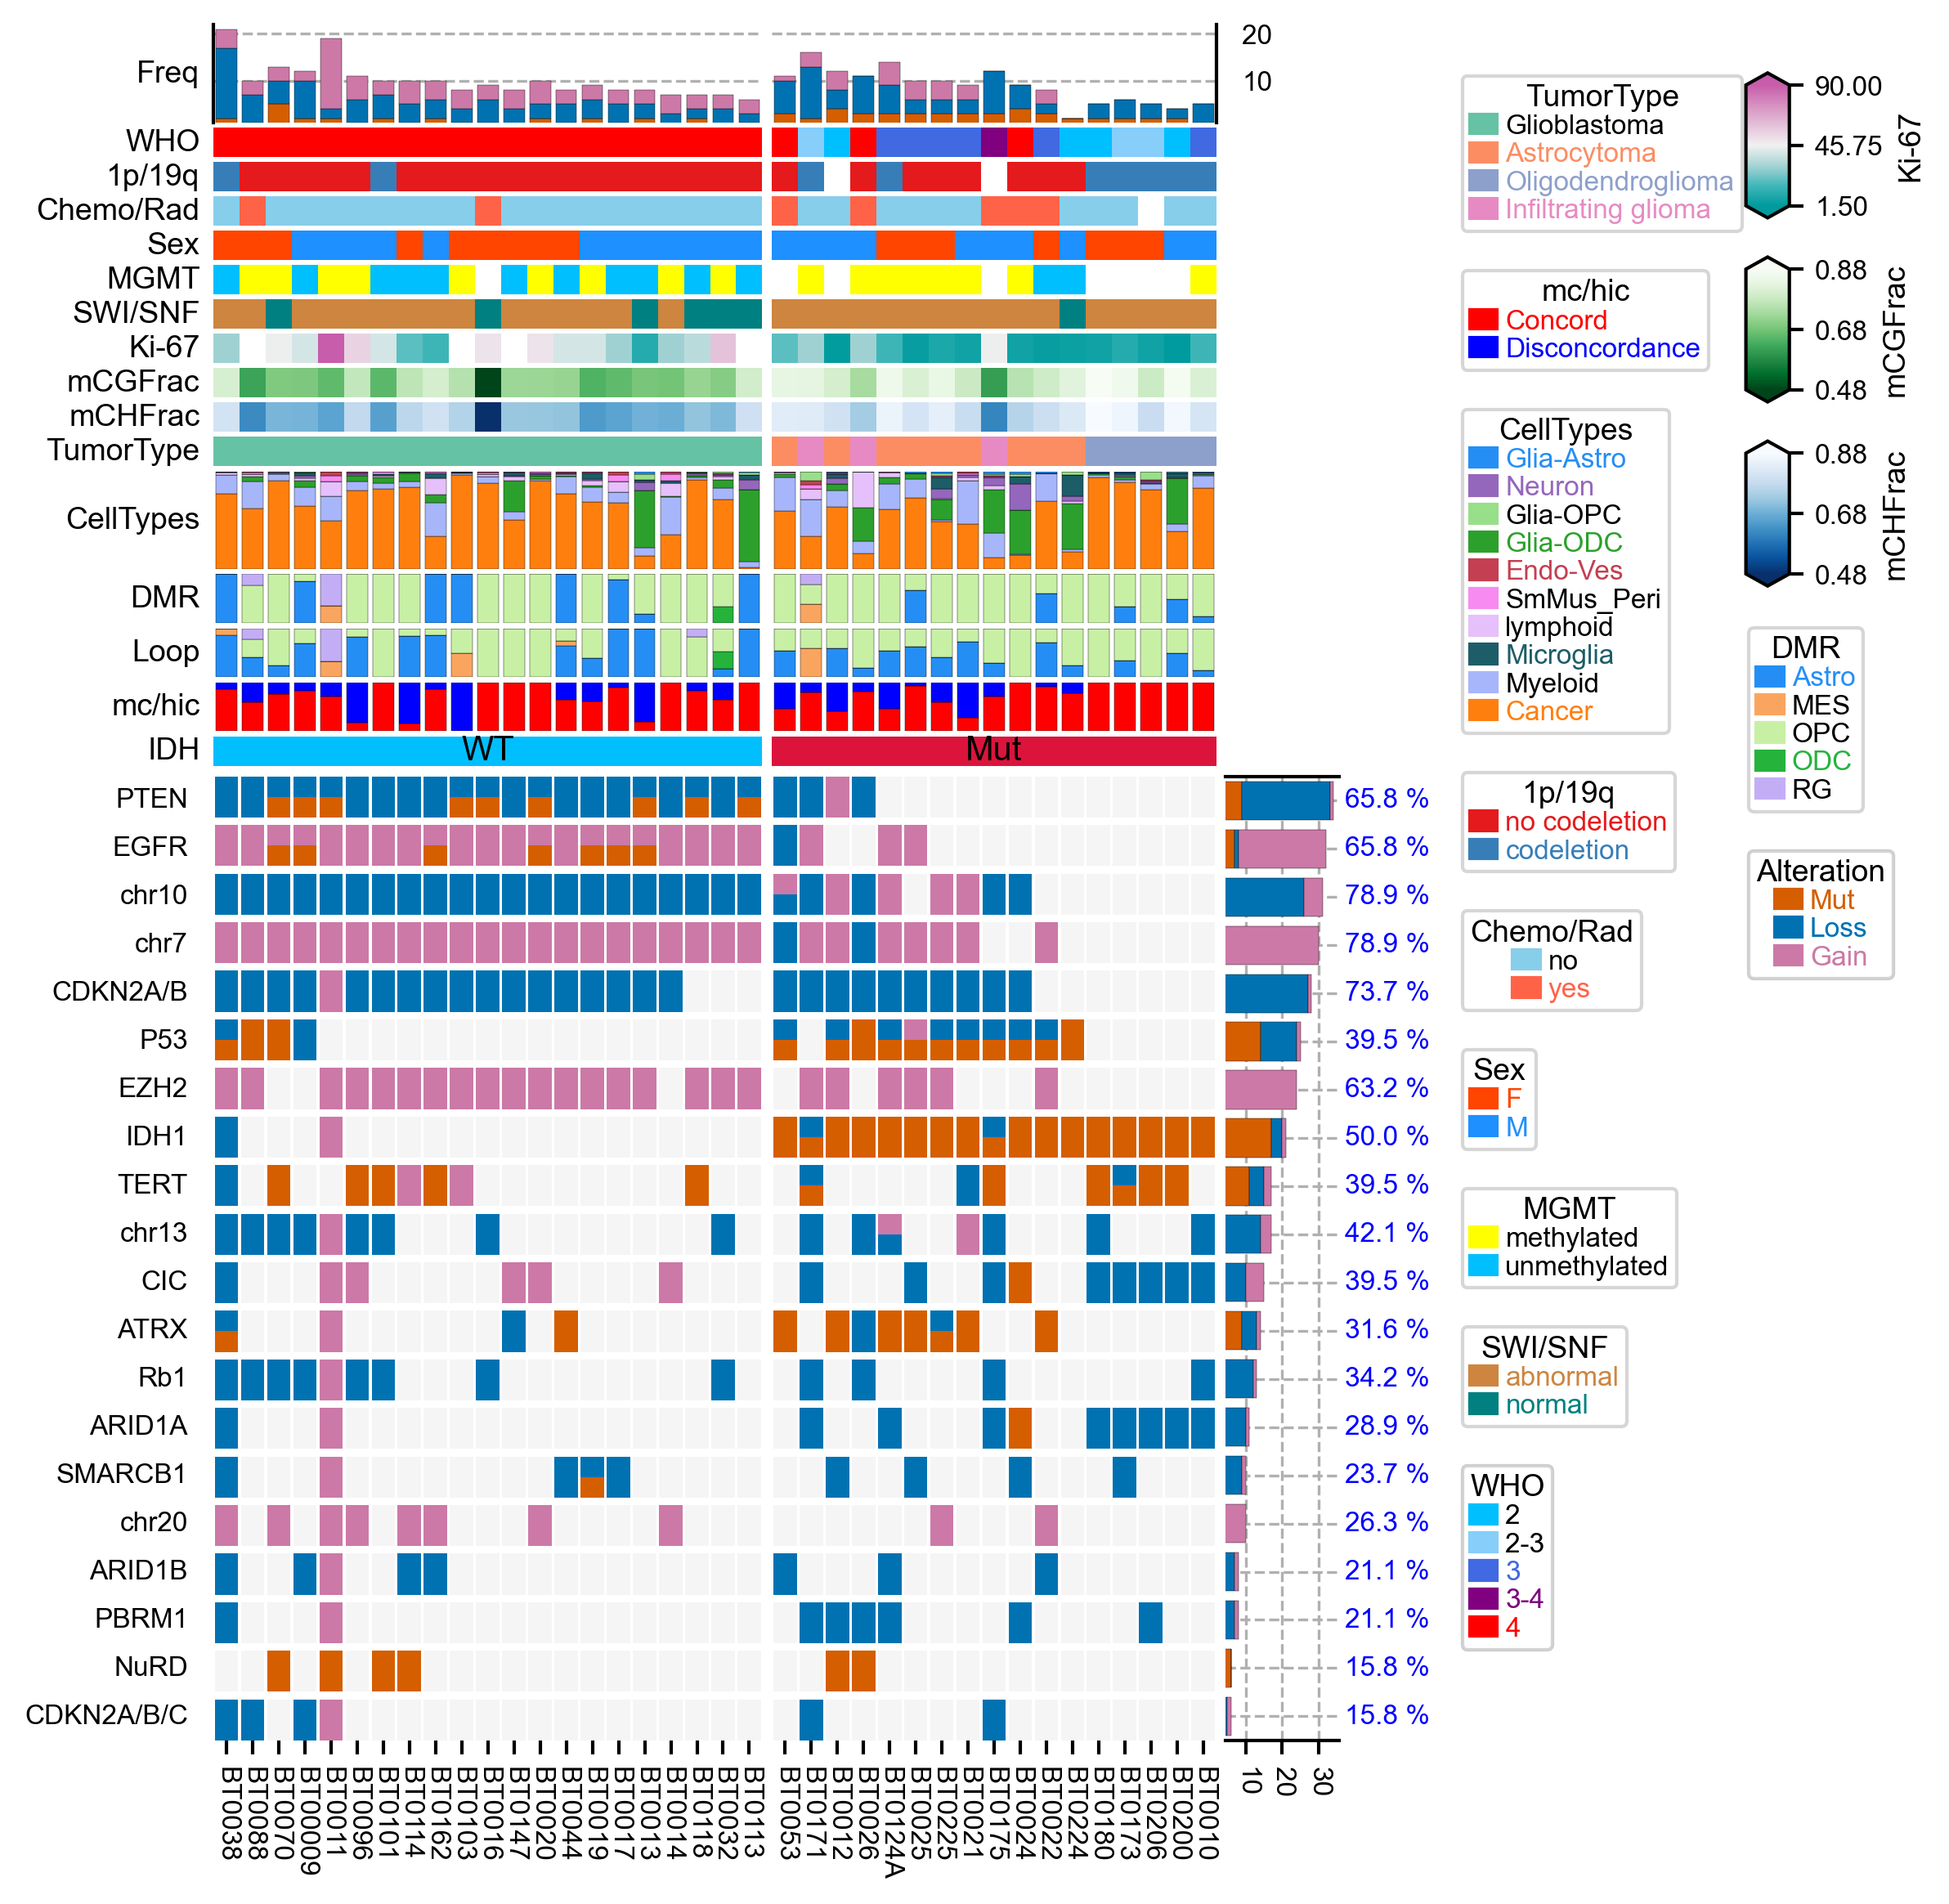

In [273]:
plt.figure(figsize=(6,8))
op=oncoPrintPlotter(data=df_oncoprint,y='Gene',x='SampleID',col_cluster=True,
                    col_split=df_donor.IDH,col_split_order=['WT','Mut'],col_split_gap=1,
                    values=cols,colors=oncoprint_colors,label='Alteration',
                    top_annotation=top_annotation,right_annotation=right_annotation,
                   show_rownames=True,show_colnames=True,width=0.9,legend_gap=5,subplot_gap=1,
                    legend_order=['TumorType','mc/hic','CellTypes','1p/19q',
                                                 'Chemo/Rad','Sex','MGMT','SWI/SNF','WHO','Ki-67',
                                                 'mCGFrac','mCHFrac','DMR','Alteration'], #legend_width=50,
                   xticklabels_kws={'labelrotation':-90,'labelcolor':'black','bottom':True},
                   )

# remove the grid
# op.top_annotation.annotations[0].ax.grid(False)
#remove spines for top annotation and right annotation
# for ax in op.top_annotation.axes[0]:
ax1=op.top_annotation.axes[0,0]
despine(ax=ax1,left=False, bottom=True, right=True, top=True) #ax=op.top_annotation.annotations[0].ax
ax2=op.top_annotation.axes[0,1]
despine(ax=ax2,left=True, bottom=True, right=False, top=True) #ax=op.top_annotation.annotations[0].ax
despine(ax=op.right_annotation.annotations[0].ax,left=True, bottom=False, right=True, top=False)

for i in range(11,15):
    for j in [0,1]:
        ax=op.top_annotation.axes[i,j]
        # ax.spines["top"].set_visible(False)
        # ax.spines["bottom"].set_visible(False)
        despine(ax=ax,left=True, bottom=True, right=True, top=True)

plt.savefig("oncoPrint.pdf",bbox_inches='tight')
plt.show()

In [243]:
row_vc=df_oncoprint.groupby('Gene').apply(lambda x:x.loc[:,cols].sum())
col_vc=df_oncoprint.groupby('SampleID').apply(lambda x:x.loc[:,cols].sum())
row_var_freq=df_oncoprint.assign(IsVar=(df_oncoprint.loc[:,cols].sum(axis=1)>0)).groupby('Gene').IsVar.sum() * 100 / df_oncoprint.SampleID.nunique()

palette_celltype = {'Glia-Astro': '#258EF5', 'Neuron':  '#9467bd', 
                'Glia-OPC':  '#98df8a', 'Glia-ODC': '#2ca02c','RG':'#c5b0d5', 'Endo-Ves': '#c43f52',
                 'SmMus_Peri':'#F78BF1','lymphoid':'#e6c0fa','Microglia':'#1d5d68','Myeloid':'#A7B6FA',
                'Cancer':'#ff7f0e'} #  'ODC': '#2ca02c', ,'Cancer-WT': '#1f77b4','MES': '#ffbb78', 
palette_idh = {'WT': '#1f77b4', 'Mut':'#ff7f0e' }
palette_state = {'Astro': '#258EF5', 'MES':'#faa55f','OPC':'#C8F0A5','ODC':'#25B33C', 'RG':'#C3AEF5','Neu':'#884BCC','Normal':'#CCCCCC'}

left_annotation=HeatmapAnnotation(axis=0,orientation='left',
                                Freq=anno_barplot(col_vc,colors=oncoprint_colors,legend=False,height=10,linewidth=0.1,grid=True),
                                WHO=anno_simple(df_donor.WHO),
                                A=anno_simple(df_donor['1p/19q Codel'].map({'0':'no codeletion','2':'codeletion'}),label="1p/19q"),
                                Chemo=anno_simple(df_donor['Chemo/Rad'].map({'0':'no','1':'yes'}),
                                                  label="Chemo/Rad",colors=dict(no='skyblue',yes='tomato')),
                                Sex=anno_simple(df_donor['Sex'].apply(lambda x:x.strip()),colors=dict(F="orangered",M='dodgerblue')),
                                MGMT=anno_simple(df_donor['MGMT methylation'],colors=dict(methylated='yellow',unmethylated='deepskyblue')),
                                SWI=anno_simple(df_donor['SWI/SNF Complex'],label="SWI/SNF",colors=dict(abnormal='peru',normal='teal')),
                                K=anno_simple(df_donor['Ki-67'],label="Ki-67",cmap='Tropic',
                                              legend_kws=dict(extend='both',extendfrac=0.1)),
                                mCGFrac=anno_simple(df_donor['mCGFrac'],cmap='Greens_r',legend_kws=dict(extend='both',extendfrac=0.1)),
                               mCHFrac=anno_simple(df_donor['mCGFrac'],cmap='Blues_r',legend_kws=dict(extend='both',extendfrac=0.1)),
                              TumorType=anno_simple(df_donor['tumor_type'],cmap='Set2'),
                              CellTypes=anno_barplot(df_ct_frac,ylim=[0,1],linewidth=0.1,colors=palette_celltype,height=10),
                              DMR=anno_barplot(df_dmr_state,ylim=[0,1],linewidth=0.1,colors=palette_state,height=5),
                              Loop=anno_barplot(df_loop_state,ylim=[0,1],linewidth=0.1,colors=palette_state,legend=False,height=5),
                              hic_state=anno_barplot(df_hic_state,ylim=[0,1],linewidth=0.1,label='mc/hic',
                                                     colors={'Concord':'red','Disconcordance':'blue'},height=5),
                             IDH=anno_simple(df_donor['IDH'],colors=dict(WT="deepskyblue",Mut="crimson"),
                                             add_text=True,legend=False,text_kws=dict(fontsize=10,fontweight='bold')),
                                verbose=0, label_side='top', hgap=0.5,
                                 ticklabels_kws={'labelbottom':False,'bottom':False,'labelrotation':45,'top':True},
                                label_kws={'rotation':45}
                                )

bottom_annotation = HeatmapAnnotation(axis=1,orientation='down',
                                Row=anno_barplot(row_vc,colors=oncoprint_colors,legend=False,height=12,linewidth=0.1,grid=True),
                                label=anno_label(row_var_freq.apply(lambda x:str(round(x,1))+" %"),colors='blue',
                                                 height=0.5,relpos=(0,0.5),arrowprops = dict(visible=False)
                                                ),
                                verbose=0, label_side='left',
                                label_kws={'horizontalalignment': 'center','rotation':45,'visible':False})

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 37.85444444444445 mm
Incresing ncol
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


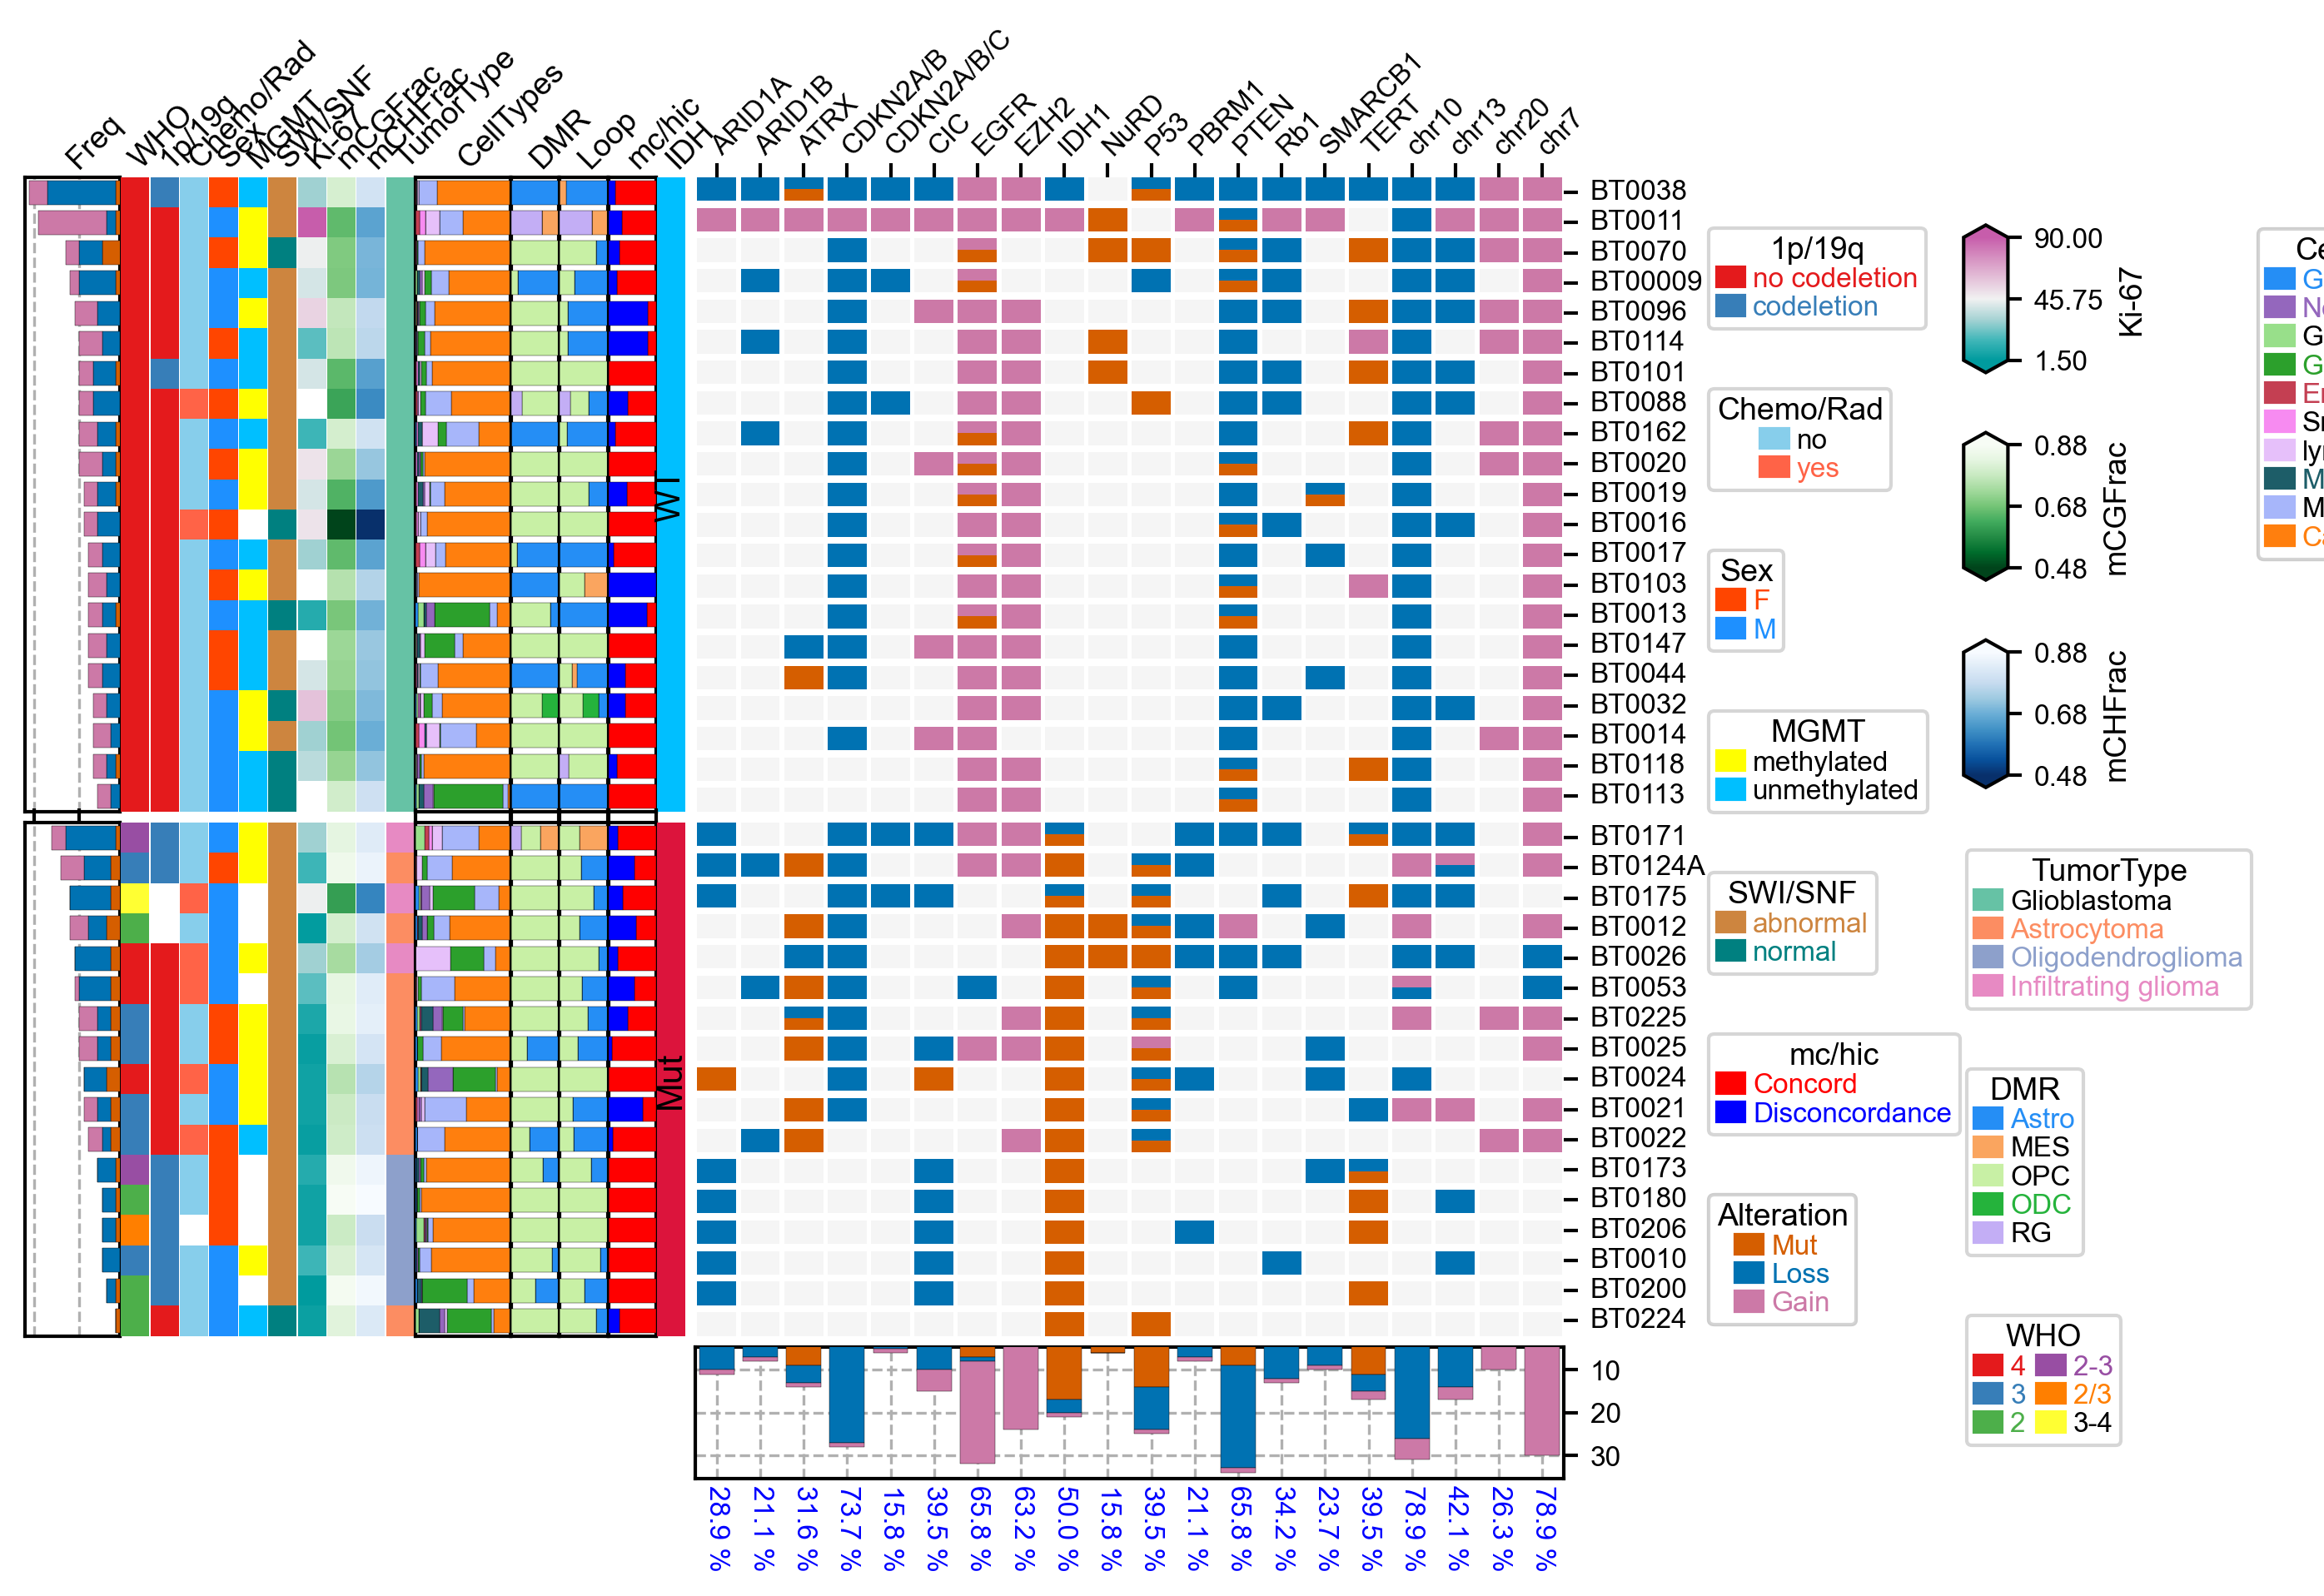

In [244]:
plt.figure(figsize=(8,6))
op=oncoPrintPlotter(data=df_oncoprint,x='Gene',y='SampleID',col_cluster=False,#row_cluster=True,
                    row_split=df_donor.IDH,row_split_order=['WT','Mut'],row_split_gap=1,
                    values=cols,colors=oncoprint_colors,label='Alteration',
                    left_annotation=left_annotation,bottom_annotation=bottom_annotation,
                   show_rownames=True,show_colnames=True,width=0.9,legend_gap=6,subplot_gap=1,
                   yticklabels_kws={'labelcolor':'black','right':True},
                    xticklabels_kws={'labelcolor':'black','top':True,'labelrotation':45},
                   )

# ax1=op.left_annotation.axes[0,0]
# despine(ax=ax1,left=False, bottom=True, right=True, top=True)
# ax2=op.left_annotation.axes[1,0]
# despine(ax=ax2,left=True, bottom=True, right=False, top=True)
# despine(ax=op.bottom_annotation.annotations[0].ax,left=True, bottom=False, right=True, top=False)

# for i in range(11,15):
#     for j in [0,1]:
#         ax=op.left_annotation.axes[j,i]
#         # ax.spines["top"].set_visible(False)
#         # ax.spines["bottom"].set_visible(False)
#         despine(ax=ax,left=True, bottom=True, right=True, top=True)

plt.savefig("oncoPrint.horizontal.pdf",bbox_inches='tight')
plt.show()